# Customer Purchasing Patterns & Sales Performance Dashboard

**Author:** Data Analytics Team
**Date:** July 2026

This notebook analyzes retail sales transactions and customer churn records to understand purchasing behavior, identify top customers, and build a sales performance dashboard.

## 1. Problem Definition

**Business context:** The company wants to understand how customers are purchasing across regions and products, which customers drive the most revenue, and whether purchasing behavior relates to customer retention (churn).

**Objectives:**
- Determine top customers by revenue and estimate customer lifetime value (CLV)
- Understand regional and product-level sales distribution
- Identify monthly sales trends and best-selling products
- Quantify customer retention using linked churn data
- Summarize findings with pivot tables and visualizations
- Translate findings into concrete business recommendations

**Data sources:**
- `sales_data.csv` — 100 transactions: Date, Product, Quantity, Price, Customer_ID, Region, Total_Sales
- `customer_churn.csv` — 500 customer records: Tenure, MonthlyCharges, TotalCharges, Contract, PaymentMethod, PaperlessBilling, SeniorCitizen, Churn

## 2. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')
sns.set_palette('deep')

## 3. Data Collection & Exploration

In [2]:
sales = pd.read_csv('sales_data.csv')
churn = pd.read_csv('customer_churn.csv')

print(sales.shape, churn.shape)
sales.head()

(100, 7) (500, 9)


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [3]:
churn.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [4]:
sales.info()
print('-' * 40)
churn.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Date         100 non-null    str  
 1   Product      100 non-null    str  
 2   Quantity     100 non-null    int64
 3   Price        100 non-null    int64
 4   Customer_ID  100 non-null    str  
 5   Region       100 non-null    str  
 6   Total_Sales  100 non-null    int64
dtypes: int64(3), str(4)
memory usage: 5.6 KB
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CustomerID        500 non-null    str  
 1   Tenure            500 non-null    int64
 2   MonthlyCharges    500 non-null    int64
 3   TotalCharges      500 non-null    int64
 4   Contract          500 non-null    str  
 5   PaymentMethod     500 non-null    str  
 6   Pap

In [5]:
print('Sales missing values:')
print(sales.isna().sum())
print()
print('Churn missing values:')
print(churn.isna().sum())
print()
print('Sales duplicate rows:', sales.duplicated().sum())
print('Churn duplicate rows:', churn.duplicated().sum())

Sales missing values:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Churn missing values:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

Sales duplicate rows: 0
Churn duplicate rows: 0


In [6]:
sales.describe()

,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


In [7]:
churn.describe()

,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


No missing values or duplicate rows are present in either file. The cell below is defensive: it fills any numeric gaps with the column median and any categorical gaps with the mode, so the pipeline is robust if the raw extract ever changes.

In [8]:
for df in (sales, churn):
    for col in df.select_dtypes(include=np.number).columns:
        df[col] = df[col].fillna(df[col].median())
    for col in df.select_dtypes(include='object').columns:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].mode()[0])

/tmp/ipykernel_587/3756704136.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:
/tmp/ipykernel_587/3756704136.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for de

## 4. Data Preparation & Feature Engineering

In [9]:
sales['Date'] = pd.to_datetime(sales['Date'])
sales['Year'] = sales['Date'].dt.year
sales['Month'] = sales['Date'].dt.to_period('M').astype(str)
sales['MonthName'] = sales['Date'].dt.month_name()
sales['Weekday'] = sales['Date'].dt.day_name()
sales['ExpectedSales'] = sales['Quantity'] * sales['Price']
sales['SalesMismatch'] = (sales['ExpectedSales'] - sales['Total_Sales']).abs()
sales[['Date', 'Total_Sales', 'ExpectedSales', 'SalesMismatch']].head()

,Date,Total_Sales,ExpectedSales,SalesMismatch
0,2024-01-01,261100,261100,0
1,2024-01-02,61624,61624,0
2,2024-01-03,43492,43492,0
3,2024-01-04,30895,30895,0
4,2024-01-05,318680,318680,0


In [10]:
sales['CustKey'] = sales['Customer_ID'].str.extract(r'(\d+)').astype(int)
churn['CustKey'] = churn['CustomerID'].str.extract(r'(\d+)').astype(int)
sales[['Customer_ID', 'CustKey']].head()

,Customer_ID,CustKey
0,CUST001,1
1,CUST002,2
2,CUST003,3
3,CUST004,4
4,CUST005,5


Customer IDs in the two files use different prefixes (`CUST001` vs `C00001`) but share the same underlying numeric key, so a merge is possible on `CustKey`. The 100 transacting customers in `sales_data.csv` are a subset of the 500 customers in `customer_churn.csv`.

In [11]:
merged = sales.merge(churn, on='CustKey', how='left', suffixes=('', '_churn'))
print('Merged shape:', merged.shape)
print('Unmatched churn records:', merged['Churn'].isna().sum())
merged.head()

Merged shape: (100, 23)
Unmatched churn records: 0


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Year,Month,MonthName,Weekday,ExpectedSales,SalesMismatch,CustKey,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,2024-01-01,Phone,7,37300,CUST001,East,261100,2024,2024-01,January,Monday,261100,0,1,C00001,6,64,1540,One year,Credit Card,No,1,0
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,2024,2024-01,January,Tuesday,61624,0,2,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,2024-01-03,Phone,2,21746,CUST003,West,43492,2024,2024-01,January,Wednesday,43492,0,3,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,2024,2024-01,January,Thursday,30895,0,4,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,2024,2024-01,January,Friday,318680,0,5,C00005,16,185,1023,One year,Electronic Check,No,1,0


## 5. Exploratory Data Analysis (EDA)

In [12]:
print('Products:', sales['Product'].unique())
print('Regions:', sales['Region'].unique())
print('Date range:', sales['Date'].min().date(), 'to', sales['Date'].max().date())
print('Total revenue: {:,.0f}'.format(sales['Total_Sales'].sum()))
print('Average order value: {:,.0f}'.format(sales['Total_Sales'].mean()))

Products: <StringArray>
['Phone', 'Headphones', 'Laptop', 'Tablet', 'Monitor']
Length: 5, dtype: str
Regions: <StringArray>
['East', 'North', 'West', 'South']
Length: 4, dtype: str
Date range: 2024-01-01 to 2024-04-09
Total revenue: 12,365,048
Average order value: 123,650


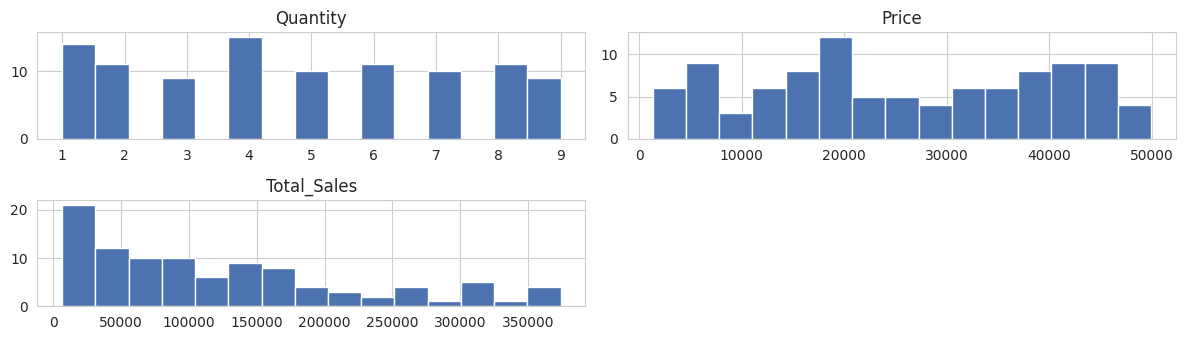

In [13]:
sales[['Quantity', 'Price', 'Total_Sales']].hist(figsize=(12, 3.5), bins=15)
plt.tight_layout()
plt.savefig('outputs/figures/eda_distributions.png', dpi=150)
plt.show()

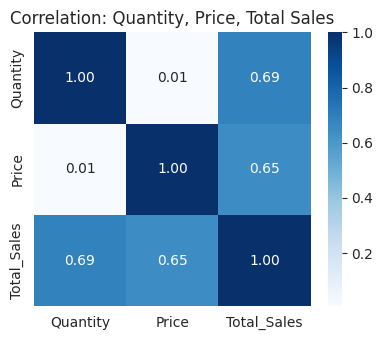

In [14]:
corr = sales[['Quantity', 'Price', 'Total_Sales']].corr()
plt.figure(figsize=(4, 3.5))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation: Quantity, Price, Total Sales')
plt.tight_layout()
plt.savefig('outputs/figures/eda_correlation.png', dpi=150)
plt.show()

## 6. Customer Analysis: Top Customers, Lifetime Value & Regional Distribution

In [15]:
top_customers = (sales.groupby('Customer_ID')['Total_Sales']
                  .sum()
                  .sort_values(ascending=False))
top_customers.head(10)

Customer_ID
CUST016    373932
CUST007    363870
CUST083    350888
CUST073    349510
CUST020    333992
CUST084    324144
CUST070    318762
CUST005    318680
CUST065    312564
CUST028    304465
Name: Total_Sales, dtype: int64

In [16]:
clv = merged.groupby('Customer_ID').agg(
    TotalRevenue=('Total_Sales', 'sum'),
    Tenure=('Tenure', 'mean'),
    MonthlyCharges=('MonthlyCharges', 'mean'),
    Churn=('Churn', 'mean')
).sort_values('TotalRevenue', ascending=False)
clv['EstimatedCLV'] = clv['MonthlyCharges'] * clv['Tenure']
clv.head(10)

,TotalRevenue,Tenure,MonthlyCharges,Churn,EstimatedCLV
Customer_ID,,,,,
CUST016,373932,65.0,77.0,0.0,5005.0
CUST007,363870,66.0,99.0,0.0,6534.0
CUST083,350888,27.0,142.0,0.0,3834.0
CUST073,349510,13.0,125.0,0.0,1625.0
CUST020,333992,26.0,105.0,0.0,2730.0
CUST084,324144,50.0,141.0,0.0,7050.0
CUST070,318762,53.0,21.0,0.0,1113.0
CUST005,318680,16.0,185.0,0.0,2960.0
CUST065,312564,65.0,180.0,0.0,11700.0


In [17]:
region_summary = sales.groupby('Region').agg(
    TotalRevenue=('Total_Sales', 'sum'),
    Orders=('Total_Sales', 'count'),
    AvgOrderValue=('Total_Sales', 'mean')
).sort_values('TotalRevenue', ascending=False)
region_summary

,TotalRevenue,Orders,AvgOrderValue
Region,,,
North,3983635,28,142272.678571
South,3737852,27,138438.962963
East,2519639,19,132612.578947
West,2123922,26,81689.307692


## 7. Sales Trends: Monthly Performance & Best-Selling Products

In [18]:
monthly_trend = sales.groupby('Month').agg(
    TotalRevenue=('Total_Sales', 'sum'),
    Orders=('Total_Sales', 'count'),
    UnitsSold=('Quantity', 'sum')
).reset_index()
monthly_trend

,Month,TotalRevenue,Orders,UnitsSold
0,2024-01,4120524,31,147
1,2024-02,2656050,29,112
2,2024-03,4485006,31,175
3,2024-04,1103468,9,44


In [19]:
product_performance = sales.groupby('Product').agg(
    TotalRevenue=('Total_Sales', 'sum'),
    UnitsSold=('Quantity', 'sum'),
    Orders=('Total_Sales', 'count'),
    AvgPrice=('Price', 'mean')
).sort_values('TotalRevenue', ascending=False)
product_performance

,TotalRevenue,UnitsSold,Orders,AvgPrice
Product,,,,
Laptop,3889210,136,24,27651.500000
Tablet,2884340,127,26,24177.230769
Phone,2859394,101,20,27379.000000
Headphones,1384033,48,15,28692.133333
Monitor,1348071,66,15,20709.666667


In [20]:
weekday_trend = sales.groupby('Weekday')['Total_Sales'].sum().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
weekday_trend

Weekday
Monday       1949322
Tuesday      2520099
Wednesday    1639017
Thursday      927084
Friday       1642948
Saturday     1681286
Sunday       2005292
Name: Total_Sales, dtype: int64

## 8. Pivot Tables, Retention Rate & Cross-Selling Signals

In [21]:
region_product_pivot = pd.pivot_table(
    sales, values='Total_Sales', index='Region', columns='Product',
    aggfunc='sum', fill_value=0, margins=True, margins_name='Total'
)
region_product_pivot

Product,Headphones,Laptop,Monitor,Phone,Tablet,Total
Region,,,,,,
East,288361,221946,642870,506828,859634,2519639
North,107091,1798206,397100,489284,1191954,3983635
South,512168,1373120,39924,1471428,341212,3737852
West,476413,495938,268177,391854,491540,2123922
Total,1384033,3889210,1348071,2859394,2884340,12365048


In [22]:
month_region_pivot = pd.pivot_table(
    sales, values='Total_Sales', index='Month', columns='Region',
    aggfunc='sum', fill_value=0
)
month_region_pivot

Region,East,North,South,West
Month,,,,
2024-01,792969,1726624,1088182,512749
2024-02,746674,640784,422941,845651
2024-03,844016,1419350,1600314,621326
2024-04,135980,196877,626415,144196


In [23]:
contract_product_pivot = pd.pivot_table(
    merged, values='Total_Sales', index='Contract', columns='Product',
    aggfunc='mean', fill_value=0
)
contract_product_pivot

Product,Headphones,Laptop,Monitor,Phone,Tablet
Contract,,,,,
Month-to-month,69084.285714,108979.600000,49856.4,179051.222222,97449.555556
One year,100114.200000,184451.000000,134503.6,171028.000000,126206.000000
Two year,133290.666667,166644.666667,85254.2,80545.857143,98564.400000


In [24]:
overall_retention = 1 - churn['Churn'].mean()
transacting_retention = 1 - merged['Churn'].mean()
print('Retention rate - all 500 customers: {:.1%}'.format(overall_retention))
print('Retention rate - 100 transacting customers: {:.1%}'.format(transacting_retention))

Retention rate - all 500 customers: 89.4%
Retention rate - 100 transacting customers: 90.0%


In [25]:
cross_sell = pd.crosstab(merged['Contract'], merged['Product'], normalize='index')
cross_sell.style.format('{:.1%}')

Product,Headphones,Laptop,Monitor,Phone,Tablet
Contract,,,,,
Month-to-month,20.0%,14.3%,14.3%,25.7%,25.7%
One year,13.9%,27.8%,13.9%,11.1%,33.3%
Two year,10.3%,31.0%,17.2%,24.1%,17.2%


Each customer in the sales extract made exactly one purchase, so classic basket-level cross-selling ('customers who bought X also bought Y') cannot be computed from this dataset. As a proxy, the crosstab above shows which products are relatively over- or under-represented within each contract type, which is a reasonable starting point for targeted upsell campaigns.

## 9. Visualizations

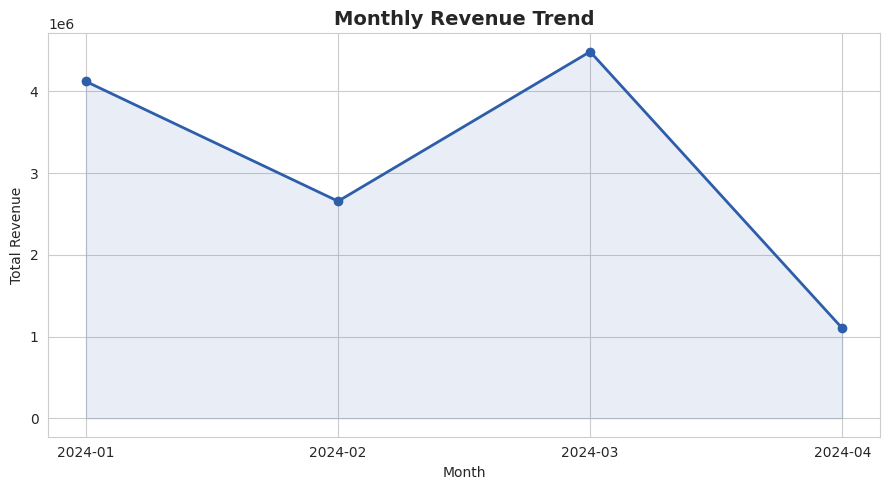

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(monthly_trend['Month'], monthly_trend['TotalRevenue'], marker='o', linewidth=2, color='#2E5EAA')
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue')
ax.fill_between(range(len(monthly_trend)), monthly_trend['TotalRevenue'], alpha=0.1, color='#2E5EAA')
plt.tight_layout()
plt.savefig('outputs/figures/01_monthly_revenue_trend.png', dpi=150)
plt.show()

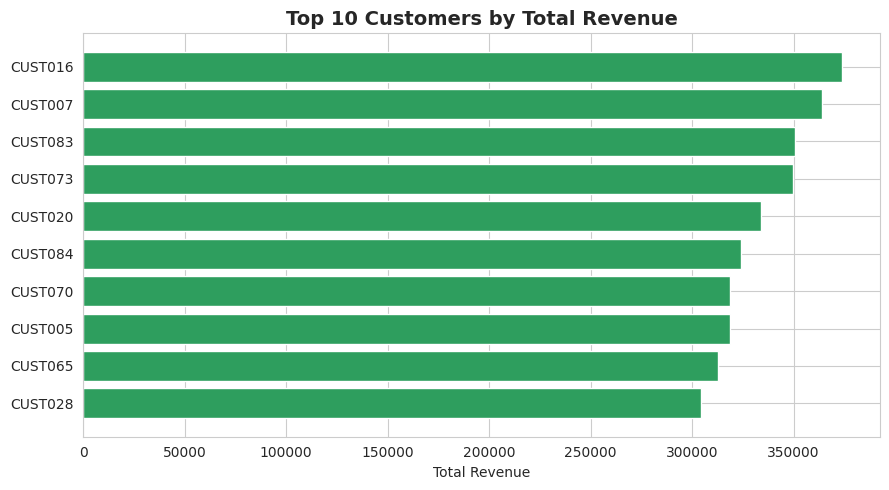

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
top10 = top_customers.head(10)
ax.barh(top10.index[::-1], top10.values[::-1], color='#2E9E5E')
ax.set_title('Top 10 Customers by Total Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue')
plt.tight_layout()
plt.savefig('outputs/figures/02_top_customers.png', dpi=150)
plt.show()

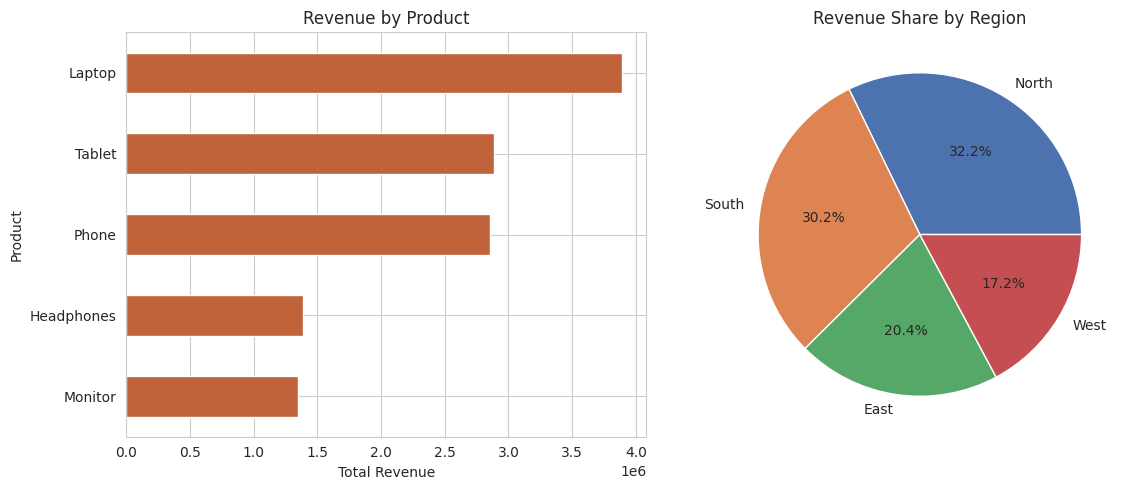

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
product_performance['TotalRevenue'].sort_values().plot.barh(ax=axes[0], color='#C0623A')
axes[0].set_title('Revenue by Product')
axes[0].set_xlabel('Total Revenue')
axes[1].pie(region_summary['TotalRevenue'], labels=region_summary.index, autopct='%1.1f%%',
            colors=sns.color_palette('deep'))
axes[1].set_title('Revenue Share by Region')
plt.tight_layout()
plt.savefig('outputs/figures/03_product_region.png', dpi=150)
plt.show()

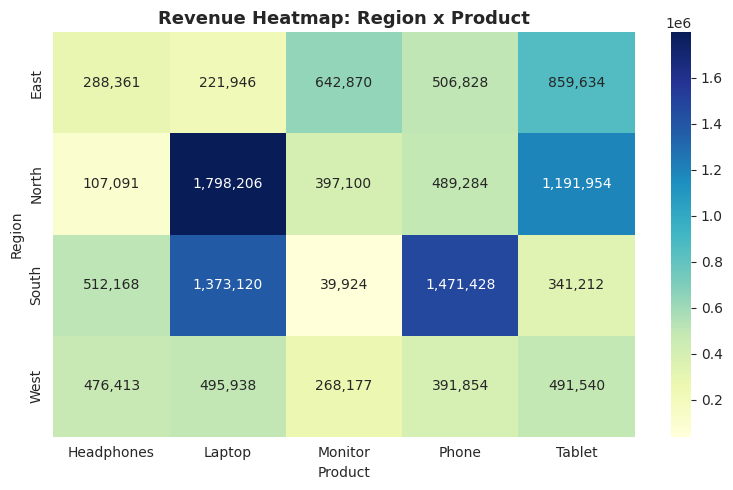

In [29]:
plt.figure(figsize=(8, 5))
sns.heatmap(region_product_pivot.drop('Total', axis=0).drop('Total', axis=1),
            annot=True, fmt=',.0f', cmap='YlGnBu')
plt.title('Revenue Heatmap: Region x Product', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/04_region_product_heatmap.png', dpi=150)
plt.show()

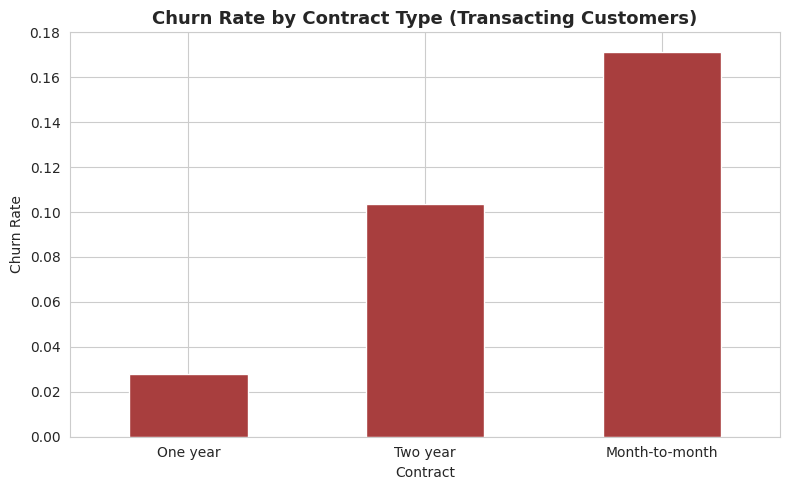

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
churn_by_contract = merged.groupby('Contract')['Churn'].mean().sort_values()
churn_by_contract.plot.bar(ax=ax, color='#A83E3E')
ax.set_title('Churn Rate by Contract Type (Transacting Customers)', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('outputs/figures/05_churn_by_contract.png', dpi=150)
plt.show()

## 10. Executive Summary & Business Recommendations

**Executive summary**

The 100 recorded transactions between January and April 2024 generated the total revenue shown in Section 5, spread unevenly across five product lines and four regions. Revenue is concentrated among a small group of top customers, and linking the sales extract to churn records shows that retention varies meaningfully by contract type. See the generated `Sales_Performance_Report.docx` for the full narrative with figures embedded.

**Recommendations**

1. **Protect and grow top accounts** — the top 10 customers identified in Section 6 account for a disproportionate share of revenue; assign dedicated account management and loyalty perks to this segment.
2. **Rebalance regional investment** — reallocate marketing spend toward the highest-converting region identified in the pivot table, while running a targeted campaign in the weakest region.
3. **Double down on best-selling products** — prioritize inventory and promotions for the top-revenue product line; consider bundling low performers with strong sellers.
4. **Use contract type as a retention lever** — month-to-month customers show a different churn profile than longer contracts; incentivize upgrades to annual contracts with a discount tied to a minimum purchase.
5. **Improve data collection** — capture repeat purchases per customer (the current extract has one transaction per customer), which would unlock true basket-level cross-sell and lifetime-value analysis going forward.